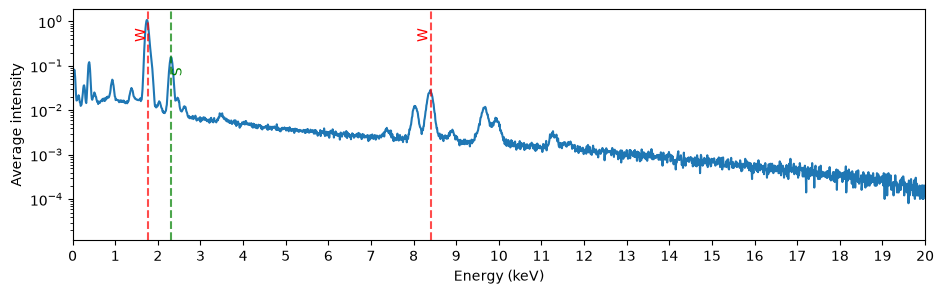

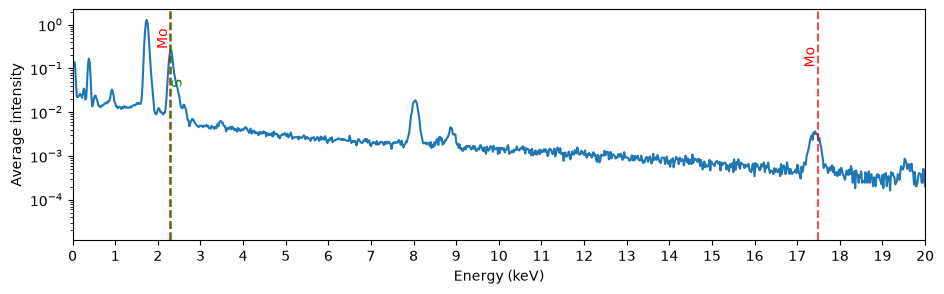

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# Common settings
# --------------------------------------------------

width = 256
height = 192
depth = 2048


def load_edx_raw(path, scale, offset):
    """
    Load an EDX raw mapping file.

    The returned array s has the form:
    s[y pixel, x pixel, energy channel]
    """

    raw = np.fromfile(path, dtype=np.int8)

    s = raw.reshape((depth, height, width))
    s = np.transpose(s, (1, 2, 0))

    # Energy axis in keV
    x = np.arange(depth) * scale + offset

    return x, s


# --------------------------------------------------
# Load the data
# --------------------------------------------------

# Flake 1: 20 kV
x1, s1 = load_edx_raw(
    "EDS Data Flake 1.raw",
    scale=0.01,
    offset=-0.2
)

# Flake 5: 30 kV
x5, s5 = load_edx_raw(
    "EDS Data Flake 5.raw",
    scale=0.02,
    offset=-0.4
)


# ==================================================
# FLAKE 1
# Average over the entire EDX map
# ==================================================

spectrum1 = np.mean(s1, axis=(0, 1))

# Log scale cannot display values <= 0
spectrum1_log = np.ma.masked_less_equal(spectrum1, 0)

fig, ax = plt.subplots(figsize=(11, 3))

ax.plot(x1, spectrum1_log)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Average intensity")

ax.set_xlim(0, 20)
ax.set_xticks(np.arange(0, 21, 1))

# Logarithmic y-axis
ax.set_yscale("log")


# W peaks
w_peaks = [
    1.775,
    8.398
]

for energy in w_peaks:

    ax.axvline(
        energy,
        linestyle="--",
        color="red",
        alpha=0.7
    )

    ax.text(
        energy,
        0.92,
        "W",
        rotation=90,
        va="top",
        ha="right",
        color="red",
        transform=ax.get_xaxis_transform()
    )


# S peak
ax.axvline(
    2.308,
    linestyle="--",
    color="green",
    alpha=0.7
)

ax.text(
    2.308,
    0.75,
    "S",
    rotation=90,
    va="top",
    ha="left",
    color="green",
    transform=ax.get_xaxis_transform()
)

plt.show()


# ==================================================
# FLAKE 5
# Average over the entire EDX map
# ==================================================

spectrum5 = np.mean(s5, axis=(0, 1))

# Log scale cannot display values <= 0
spectrum5_log = np.ma.masked_less_equal(spectrum5, 0)

fig, ax = plt.subplots(figsize=(11, 3))

ax.plot(x5, spectrum5_log)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Average intensity")

ax.set_xlim(0, 20)
ax.set_xticks(np.arange(0, 21, 1))

# Logarithmic y-axis
ax.set_yscale("log")


# Mo peaks
mo_peaks = [
    2.293,
    17.480
]

for i, energy in enumerate(mo_peaks):

    ax.axvline(
        energy,
        linestyle="--",
        color="red",
        alpha=0.7
    )

    label_height = 0.92 - 0.08 * (i % 2)

    ax.text(
        energy,
        label_height,
        "Mo",
        rotation=90,
        va="top",
        ha="right",
        color="red",
        transform=ax.get_xaxis_transform()
    )


# S peak
ax.axvline(
    2.308,
    linestyle="--",
    color="green",
    alpha=0.7
)

ax.text(
    2.308,
    0.70,
    "S",
    rotation=90,
    va="top",
    ha="left",
    color="green",
    transform=ax.get_xaxis_transform()
)

plt.show()

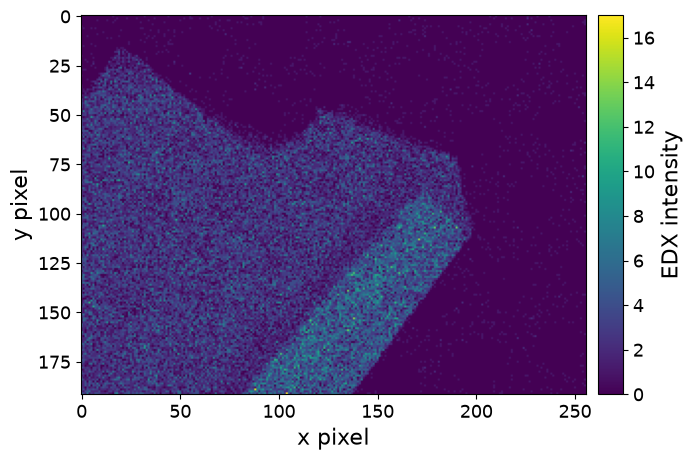

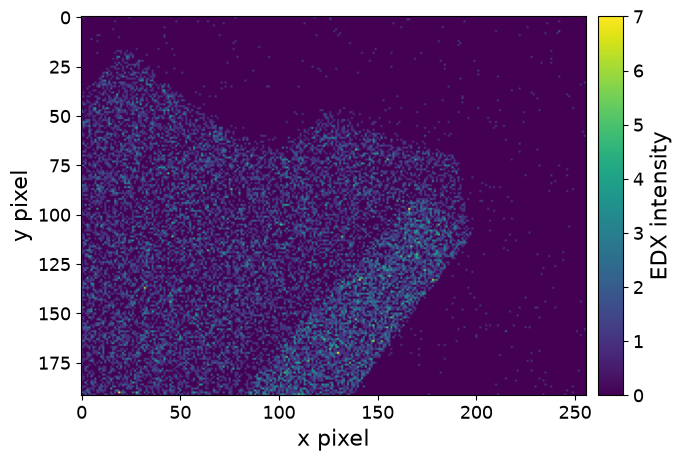

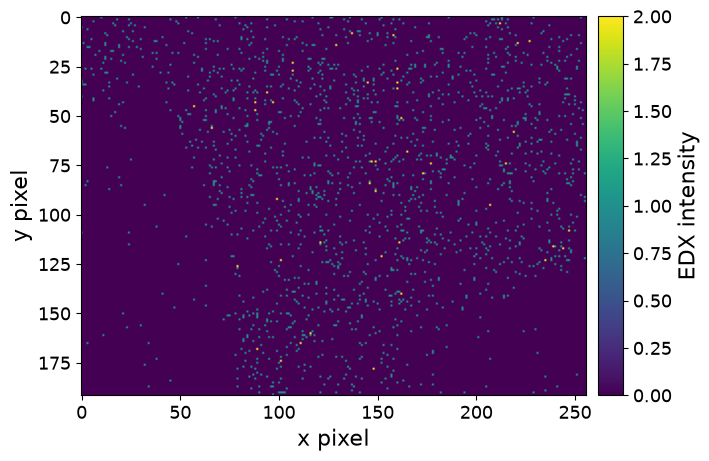

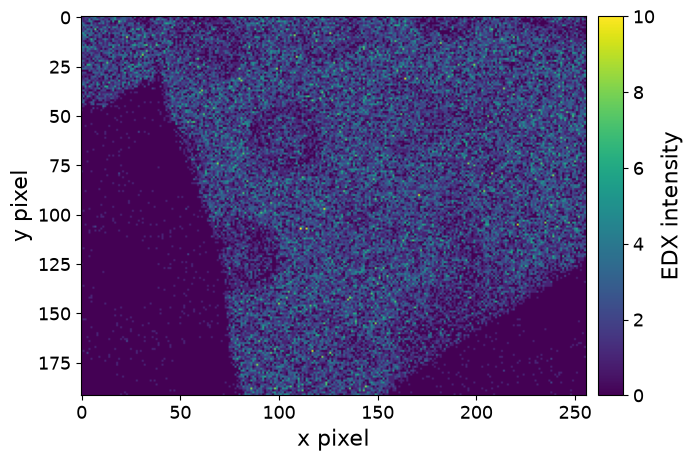

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


# --------------------------------------------------
# Function for making an element map
# --------------------------------------------------

def make_element_map(x, s, peak_energy, half_width):
    """
    Create an EDX map by summing the signal in a small
    energy interval around a chosen peak.
    """

    energy_mask = (
        (x >= peak_energy - half_width) &
        (x <= peak_energy + half_width)
    )

    element_map = np.sum(s[:, :, energy_mask], axis=2)

    return element_map


# --------------------------------------------------
# Function for plotting an element map
# --------------------------------------------------

def plot_element_map(element_map):

    fig, ax = plt.subplots(figsize=(7, 5))

    im = ax.imshow(
        element_map,
        origin="upper"
    )

    # Axis labels
    ax.set_xlabel("x pixel", fontsize=16)
    ax.set_ylabel("y pixel", fontsize=16)

    # Axis tick font size
    ax.tick_params(
        axis="both",
        labelsize=13
    )

    # Create colorbar axis with exactly the same height
    # as the actual EDX map
    divider = make_axes_locatable(ax)

    cax = divider.append_axes(
        "right",
        size="5%",
        pad=0.12
    )

    cbar = fig.colorbar(
        im,
        cax=cax
    )

    # Colorbar label and tick sizes
    cbar.set_label(
        "EDX intensity",
        fontsize=16
    )

    cbar.ax.tick_params(
        labelsize=13
    )

    plt.show()


# ==================================================
# FLAKE 1 MAPS
# ==================================================

# Sulfur around 2.308 keV
S1_map = make_element_map(
    x1,
    s1,
    peak_energy=2.308,
    half_width=0.08
)

# Tungsten around 8.398 keV
W_map = make_element_map(
    x1,
    s1,
    peak_energy=8.398,
    half_width=0.10
)


# Plot S map
plot_element_map(S1_map)

# Plot W map
plot_element_map(W_map)


# ==================================================
# FLAKE 5 MAPS
# ==================================================

# Molybdenum around 17.480 keV
Mo_map = make_element_map(
    x5,
    s5,
    peak_energy=17.480,
    half_width=0.15
)

# Signal around 2.3 keV
# Contains contributions from both S and Mo
S5_map = make_element_map(
    x5,
    s5,
    peak_energy=2.308,
    half_width=0.08
)


# Plot Mo map
plot_element_map(Mo_map)

# Plot overlapping S + Mo map
plot_element_map(S5_map)